In [2]:
import math
import random
import numpy as np
import gym
from gym import Env, spaces
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import namedtuple, deque
from pythermalcomfort.models import pmv_ppd
from datetime import timedelta
from typing import Tuple
import pygame
import pandas as pd
from gym import spaces

In [132]:
class AdversarialBuildingEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, alpha=1, beta=1, EER=11, adversarial_prob=0.4, adversarial_fraction=0.2):
        # super(150, 150, 150, AdversarialBuildingEnv, self).__init__()
        super(AdversarialBuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER
        self.adversarial_prob = adversarial_prob 
        self.adversarial_fraction = adversarial_fraction  # fraction of users to perturb
        self.room_width, self.room_height = 800, 600

        self.action_space = spaces.Discrete(9)  
        low = np.array([-10.0, 0.0, -3.0])  
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)

        self.time_step = 0
        self.max_steps = 48  

        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()

        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.generate_user_feedback()
        self.hvac_power = 0.0

        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': []
        }

    #fixed
    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)  # peaks at 2 PM
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:  # normal work hours
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:  # lunch hour (peak)
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:  # transition hours
            occupancy = np.random.uniform(0.2, 0.5)
        else:  # off hours
            occupancy = np.random.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 2.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            return 0, 0 

        pmv_values = []
        non_adv_pmv = []
        adversarial_users = set()

        num_adversarial = int(self.adversarial_fraction * self.num_users)
        adversarial_users = set(random.sample(range(self.num_users), num_adversarial))


        for idx, user in enumerate(self.users):
            met = user['met']
            clo = user['clo']
            pmv = self.calculate_pmv(met, clo)
            
            if idx in adversarial_users:
                pmv = self.apply_adversarial(pmv) 
            else:
                non_adv_pmv.append(pmv)  
            pmv_values.append(pmv)
            

        self.user_feedback = np.mean(pmv_values) if pmv_values else 0
        self.nonadv_user_feedback = np.mean(non_adv_pmv) if non_adv_pmv else 0

        return

    #fixed
    def apply_adversarial(self, pmv):
        extreme_values = [2, 2.5, 3]
        return np.sign(pmv) * random.choice(extreme_values)

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp
        tr = tdb  # mean radiant temperature
        rh = 50.0  # relative humidity
        v = 0.1  # air velocity

        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, constant_setpoint=None):
        if constant_setpoint is not None:
            self.setpoint_temp = constant_setpoint
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER  # simplified power model

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_influence + hvac_influence

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)  # only energy consumption penalty
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 100.0  # normalize energy consumption
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)

        self.history['indoor_temp'].append(self.indoor_temp)    
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}
    
    def get_pmv_wo_adv(self):
        if self.num_users == 0:
            # print("no users")
            reward = -self.beta * (self.hvac_power / 100.0)  # only energy consumption penalty
        else:
            comfort_penalty = abs(self.nonadv_user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 100.0  # normalize energy consumption
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        return reward

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.generate_user_feedback()
        self.hvac_power = 0.0

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state

    def render(self):
        pass

In [154]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 128)
        self.layer4 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

class DQNAgent:
    def __init__(self, n_observations, n_actions, device, memory_size=10000, batch_size=64, gamma=0.99, 
                 eps_start=0.9, eps_end=0.05, eps_decay=2000, tau=0.005, lr=1e-4):
        self.n_observations = n_observations
        self.n_actions = n_actions
        self.device = device
        self.batch_size = batch_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.tau = tau
        self.lr = lr

        self.policy_net = DQN(n_observations, n_actions).to(device)
        self.target_net = DQN(n_observations, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayMemory(memory_size)

        self.steps_done = 0

    def select_action(self, state):
        # epsilon-greedy strategy
        sample = random.random()
        eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
            math.exp(-1. * self.steps_done / self.eps_decay)
        self.steps_done += 1
        if sample > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()
        for target_param, param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

    def load_model(self, model_path):
        """
        Load a saved policy network from a .pth file into the agent's policy network and update the target network.
        """
        checkpoint = torch.load(model_path, map_location=self.device)
        self.policy_net.load_state_dict(checkpoint)
        self.target_net.load_state_dict(checkpoint)
        self.target_net.eval()
        print(f"Model loaded successfully from {model_path}")

In [134]:
def train_agent(agent, env, episodes):
    rewards = []
    rewards_wo_adv = []
    energy_consumptions = []
    for episode in range(episodes):
        state = env.reset()
        state = torch.tensor([state], dtype=torch.float32).to(agent.device)
        total_reward = 0
        total_energy = 0
        total_reward_no_adv = 0
        for t in range(env.max_steps):
            action = agent.select_action(state)
            
            next_state, reward, done, _ = env.step(action.item())
            reward = torch.tensor([reward], device=agent.device)
            total_reward += reward.item()

            reward_wo_adv = env.get_pmv_wo_adv()
            reward_wo_adv = torch.tensor([reward_wo_adv], device=agent.device)
            total_reward_no_adv += reward_wo_adv.item()

            total_energy += env.hvac_power
            if not done:
                next_state_tensor = torch.tensor([next_state], dtype=torch.float32).to(agent.device)
            else:
                next_state_tensor = None

            agent.memorize(state, action, next_state_tensor, reward)
            state = next_state_tensor

            agent.optimize_model()
            
        rewards.append(total_reward) # Rewards is a list of increasing cumulative rewards
        rewards_wo_adv.append(total_reward_no_adv)
        energy_consumptions.append(total_energy)
        if (episode + 1) % 10 == 0:
            print(f"Episode {episode + 1}/{episodes} - Reward w adv: {total_reward:.2f}, Reward wo adv: {total_reward_no_adv:.2f}")
    return rewards, energy_consumptions, rewards_wo_adv

In [135]:
import warnings
warnings.filterwarnings('ignore')

def run_multiple_trials(num_trials, env_with_adv, episodes):
    print("------ RUNNING multiple experiments for env:" + str(env_with_adv))
    all_rewards = []
    all_rewards_wo_ad = []
    for i in range(num_trials):
        print("TRIAL: #" + str(i))
        env_with_adv.reset()
        # env_with_adv = AdversarialBuildingEnv(adversarial_prob=1, adversarial_fraction=adversarial_fraction)
        agent_with_adv = DQNAgent(n_observations=env_with_adv.observation_space.shape[0], n_actions=env_with_adv.action_space.n, device=device)
        rewards_with_adv, _, rewards_wo_adv = train_agent(agent_with_adv, env_with_adv, episodes=episodes)
        all_rewards.append(rewards_with_adv)
        all_rewards_wo_ad.append(rewards_wo_adv)
    return all_rewards, all_rewards_wo_ad

In [136]:
num_trials = 5
EPISODES = 150
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [137]:
reward_adv_0, reward_wo_adv_0  = run_multiple_trials(num_trials, AdversarialBuildingEnv(adversarial_prob=0, adversarial_fraction=0), EPISODES)

------ RUNNING multiple experiments for env:<AdversarialBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -13.71, Reward wo adv: -13.71
Episode 20/150 - Reward w adv: -17.85, Reward wo adv: -17.85
Episode 30/150 - Reward w adv: -16.41, Reward wo adv: -16.41
Episode 40/150 - Reward w adv: -11.84, Reward wo adv: -11.84
Episode 50/150 - Reward w adv: -10.37, Reward wo adv: -10.37
Episode 60/150 - Reward w adv: -10.43, Reward wo adv: -10.43
Episode 70/150 - Reward w adv: -10.99, Reward wo adv: -10.99
Episode 80/150 - Reward w adv: -9.81, Reward wo adv: -9.81
Episode 90/150 - Reward w adv: -11.66, Reward wo adv: -11.66
Episode 100/150 - Reward w adv: -8.02, Reward wo adv: -8.02
Episode 110/150 - Reward w adv: -8.13, Reward wo adv: -8.13
Episode 120/150 - Reward w adv: -8.32, Reward wo adv: -8.32
Episode 130/150 - Reward w adv: -10.24, Reward wo adv: -10.24
Episode 140/150 - Reward w adv: -9.73, Reward wo adv: -9.73
Episode 150/150 - Reward w adv: -10.75, Reward wo adv: -10.75
T

In [138]:
reward_adv_1, reward_wo_adv_1 = run_multiple_trials(num_trials, AdversarialBuildingEnv(adversarial_prob=1, adversarial_fraction=0.1), EPISODES)

------ RUNNING multiple experiments for env:<AdversarialBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -15.60, Reward wo adv: -13.88
Episode 20/150 - Reward w adv: -14.58, Reward wo adv: -12.95
Episode 30/150 - Reward w adv: -14.65, Reward wo adv: -13.09
Episode 40/150 - Reward w adv: -13.65, Reward wo adv: -12.06
Episode 50/150 - Reward w adv: -12.82, Reward wo adv: -11.25
Episode 60/150 - Reward w adv: -10.70, Reward wo adv: -9.23
Episode 70/150 - Reward w adv: -13.48, Reward wo adv: -11.88
Episode 80/150 - Reward w adv: -10.15, Reward wo adv: -8.78
Episode 90/150 - Reward w adv: -14.51, Reward wo adv: -12.92
Episode 100/150 - Reward w adv: -11.65, Reward wo adv: -10.26
Episode 110/150 - Reward w adv: -9.55, Reward wo adv: -8.16
Episode 120/150 - Reward w adv: -13.14, Reward wo adv: -11.47
Episode 130/150 - Reward w adv: -10.69, Reward wo adv: -9.09
Episode 140/150 - Reward w adv: -9.14, Reward wo adv: -7.78
Episode 150/150 - Reward w adv: -9.30, Reward wo adv: -7.92


In [139]:
reward_adv_3, reward_wo_adv_3 = run_multiple_trials(num_trials, AdversarialBuildingEnv(adversarial_prob=1, adversarial_fraction=0.3), EPISODES)

------ RUNNING multiple experiments for env:<AdversarialBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -21.62, Reward wo adv: -16.60
Episode 20/150 - Reward w adv: -17.60, Reward wo adv: -12.51
Episode 30/150 - Reward w adv: -18.05, Reward wo adv: -13.23
Episode 40/150 - Reward w adv: -17.57, Reward wo adv: -12.60
Episode 50/150 - Reward w adv: -15.56, Reward wo adv: -10.69
Episode 60/150 - Reward w adv: -15.56, Reward wo adv: -10.96
Episode 70/150 - Reward w adv: -12.66, Reward wo adv: -8.53
Episode 80/150 - Reward w adv: -12.71, Reward wo adv: -8.45
Episode 90/150 - Reward w adv: -14.57, Reward wo adv: -9.87
Episode 100/150 - Reward w adv: -12.16, Reward wo adv: -7.88
Episode 110/150 - Reward w adv: -12.15, Reward wo adv: -8.00
Episode 120/150 - Reward w adv: -13.20, Reward wo adv: -8.89
Episode 130/150 - Reward w adv: -12.11, Reward wo adv: -7.91
Episode 140/150 - Reward w adv: -12.81, Reward wo adv: -8.54
Episode 150/150 - Reward w adv: -12.20, Reward wo adv: -8.05


In [140]:
reward_adv_5, reward_wo_adv_5 = run_multiple_trials(num_trials, AdversarialBuildingEnv(adversarial_prob=1, adversarial_fraction=0.5), EPISODES)

------ RUNNING multiple experiments for env:<AdversarialBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -26.58, Reward wo adv: -18.23
Episode 20/150 - Reward w adv: -24.26, Reward wo adv: -15.03
Episode 30/150 - Reward w adv: -21.30, Reward wo adv: -13.04
Episode 40/150 - Reward w adv: -16.44, Reward wo adv: -9.07
Episode 50/150 - Reward w adv: -20.72, Reward wo adv: -12.89
Episode 60/150 - Reward w adv: -18.07, Reward wo adv: -10.36
Episode 70/150 - Reward w adv: -17.52, Reward wo adv: -9.69
Episode 80/150 - Reward w adv: -19.41, Reward wo adv: -11.39
Episode 90/150 - Reward w adv: -19.53, Reward wo adv: -11.41
Episode 100/150 - Reward w adv: -16.92, Reward wo adv: -9.49
Episode 110/150 - Reward w adv: -15.60, Reward wo adv: -8.49
Episode 120/150 - Reward w adv: -15.85, Reward wo adv: -8.77
Episode 130/150 - Reward w adv: -15.26, Reward wo adv: -8.48
Episode 140/150 - Reward w adv: -16.93, Reward wo adv: -9.83
Episode 150/150 - Reward w adv: -17.41, Reward wo adv: -10.2

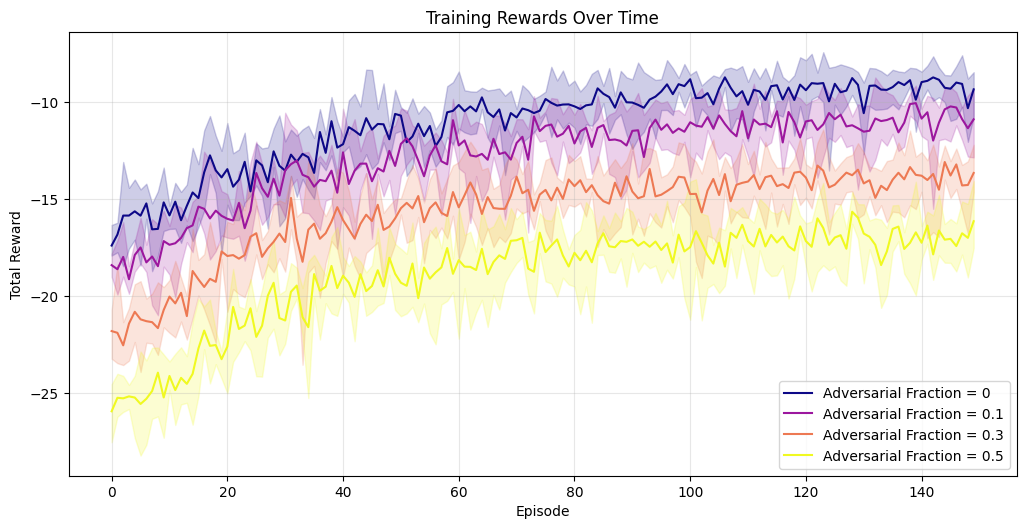

In [149]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap('plasma')

# Define the number of curves
num_curves = 4
colors = [cmap(i / (num_curves - 1)) for i in range(num_curves)]

fig = plt.figure(figsize=(20, 15))
ax1 = plt.subplot(3, 2, 1)

# List of datasets and labels
datasets = [
    (reward_adv_0, 'Adversarial Fraction = 0'),
    (reward_adv_1, 'Adversarial Fraction = 0.1'),
    (reward_adv_3, 'Adversarial Fraction = 0.3'),
    (reward_adv_5, 'Adversarial Fraction = 0.5'),
]

# Plot each dataset
for idx, (data, label) in enumerate(datasets):
    mean_values = np.mean(data, axis=0)
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    ax1.plot(mean_values, color=colors[idx], label=label)
    ax1.fill_between(range(len(mean_values)), min_values, max_values, color=colors[idx], alpha=0.2)

# Customize the plot
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Training Rewards Over Time')
ax1.grid(True, alpha=0.3)
ax1.legend()

plt.tight_layout()
plt.show()

In [97]:
class IrrationalBuildingEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, alpha=1, beta=1, EER=11, irrational_B=0):
        super(IrrationalBuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER
        self.irrational_B = irrational_B 
        self.room_width, self.room_height = 800, 600

        self.action_space = spaces.Discrete(9)  
        low = np.array([-10.0, 0.0, -3.0])  
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)

        self.time_step = 0
        self.max_steps = 48  

        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()

        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.generate_user_feedback()
        self.hvac_power = 0.0

        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': []
        }

    #fixed
    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)  # peaks at 2 PM
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:  # normal work hours
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:  # lunch hour (peak)
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:  # transition hours
            occupancy = np.random.uniform(0.2, 0.5)
        else:  # off hours
            occupancy = np.random.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 2.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            return 0, 0 

        pmv_values = []
        for idx, user in enumerate(self.users):
            met = user['met']
            clo = user['clo']
            pmv = self.calculate_pmv(met, clo)
            pmv_values.append(pmv)
            
        irrational_pmv = self.apply_irrational(pmv_values)
        self.user_feedback = np.mean(irrational_pmv) 
        self.nonirr_user_feedback = np.mean(pmv) 

        return
    
    # def apply_irrational(self, pmv:pd.Series):
    #     """Given an array of pmv score, apply irrationality to it and return an array of new pmvs of the same size.
    #     PMV values closer to the original PMV value is more likely than PMV values further away to be chosen"""
    #     # Define possible values from -3 to 3
    #     possible_values = np.arange(-3, 4)
        
    #     # Calculate probabilities for each possible value based on distance from pmv
    #     possible_values = possible_values[:, np.newaxis]

    #     differences = np.abs(possible_values - pmv)
    #     numerators = np.exp(-differences * self.irrational_B)  # Adjust with irrationality factor
    #     probabilities = numerators / numerators.sum()  # Normalize to get probabilities
        
    #     # Randomly choose an irrational value based on computed probabilities
    #     chosen_value = np.random.choice(possible_values, p=probabilities)
    #     print("IRRATIONAL!!!")
    #     print(pmv.concat(chosen_value))
    #     return chosen_value
    def apply_irrational(self, pmv: pd.Series):
        """
        Given an array of pmv scores, apply irrationality to each value and return an array 
        of new pmvs of the same size. PMV values closer to the original PMV value are more 
        likely to be chosen than PMV values further away.
        
        Args:
            pmv: pd.Series of PMV values
            
        Returns:
            np.array of irrationally adjusted PMV values
        """
        # Convert input to numpy array if it's not already
        pmv_values = np.array(pmv)
        
        # Define possible values from -3 to 3 with 0.5 steps
        possible_values = np.arange(-3, 3.5, 1)
        
        # Reshape arrays for broadcasting:
        # possible_values: (n_possibilities, 1)
        # pmv_values: (1, n_occupants)
        possible_values_reshaped = possible_values[:, np.newaxis]
        pmv_values_reshaped = pmv_values[np.newaxis, :]
        
        # Calculate differences - will result in a matrix of shape (n_possibilities, n_occupants)
        differences = np.abs(possible_values_reshaped - pmv_values_reshaped)
        
        # Calculate probabilities for each possible value based on distance from pmv
        numerators = np.exp(-differences * self.irrational_B)
        
        # Normalize probabilities along the possible_values axis
        probabilities = numerators / numerators.sum(axis=0)
        
        # Initialize array for results
        chosen_values = np.zeros_like(pmv_values)
        
        # Choose values for each occupant
        for i in range(len(pmv_values)):
            chosen_values[i] = np.random.choice(possible_values, p=probabilities[:, i])
        
        return chosen_values


    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp
        tr = tdb  # mean radiant temperature
        rh = 50.0  # relative humidity
        v = 0.1  # air velocity

        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, constant_setpoint=None):
        if constant_setpoint is not None:
            self.setpoint_temp = constant_setpoint
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER  # simplified power model

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_influence + hvac_influence

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)  # only energy consumption penalty
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 100.0  # normalize energy consumption
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)

        self.history['indoor_temp'].append(self.indoor_temp)    
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}
    
    def get_pmv_wo_irr(self):
        if self.num_users == 0:
            # print("no users")
            reward = -self.beta * (self.hvac_power / 100.0)  # only energy consumption penalty
        else:
            comfort_penalty = abs(self.nonirr_user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 100.0  # normalize energy consumption
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        return reward

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.generate_user_feedback()
        self.hvac_power = 0.0

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state

    def render(self):
        pass

In [98]:
def train_irr_agent(agent, env, episodes):
    rewards = []
    rewards_wo_adv = []
    energy_consumptions = []
    for episode in range(episodes):
        state = env.reset()
        state = torch.tensor([state], dtype=torch.float32).to(agent.device)
        total_reward = 0
        total_energy = 0
        total_reward_no_adv = 0
        for t in range(env.max_steps):
            action = agent.select_action(state)
            
            next_state, reward, done, _ = env.step(action.item())
            reward = torch.tensor([reward], device=agent.device)
            total_reward += reward.item()

            reward_wo_adv = env.get_pmv_wo_irr()
            reward_wo_adv = torch.tensor([reward_wo_adv], device=agent.device)
            total_reward_no_adv += reward_wo_adv.item()

            total_energy += env.hvac_power
            if not done:
                next_state_tensor = torch.tensor([next_state], dtype=torch.float32).to(agent.device)
            else:
                next_state_tensor = None

            agent.memorize(state, action, next_state_tensor, reward)
            state = next_state_tensor

            agent.optimize_model()
            
        rewards.append(total_reward) # Rewards is a list of increasing cumulative rewards
        rewards_wo_adv.append(total_reward_no_adv)
        energy_consumptions.append(total_energy)
        if (episode + 1) % 10 == 0:
            print(f"Episode {episode + 1}/{episodes} - Reward w adv: {total_reward:.2f}, Reward wo adv: {total_reward_no_adv:.2f}")
    return rewards, energy_consumptions, rewards_wo_adv

In [99]:
import warnings
warnings.filterwarnings('ignore')

def run_multiple_irr_trials(num_trials, env_with_adv, episodes):
    print("------ RUNNING multiple experiments for env:" + str(env_with_adv))
    all_rewards = []
    all_rewards_wo_ad = []
    for i in range(num_trials):
        print("TRIAL: #" + str(i))
        env_with_adv.reset()
        # env_with_adv = AdversarialBuildingEnv(adversarial_prob=1, adversarial_fraction=adversarial_fraction)
        agent_with_adv = DQNAgent(n_observations=env_with_adv.observation_space.shape[0], n_actions=env_with_adv.action_space.n, device=device)
        rewards_with_adv, _, rewards_wo_adv = train_irr_agent(agent_with_adv, env_with_adv, episodes=episodes)
        all_rewards.append(rewards_with_adv)
        all_rewards_wo_ad.append(rewards_wo_adv)
    return all_rewards, all_rewards_wo_ad

In [111]:
reward_irr_0, reward_wo_irr_0 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=0), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -2.29, Reward wo adv: -17.51
Episode 20/150 - Reward w adv: -2.03, Reward wo adv: -17.10
Episode 30/150 - Reward w adv: -2.09, Reward wo adv: -15.91
Episode 40/150 - Reward w adv: -1.67, Reward wo adv: -17.96
Episode 50/150 - Reward w adv: -2.17, Reward wo adv: -19.64
Episode 60/150 - Reward w adv: -1.72, Reward wo adv: -19.13
Episode 70/150 - Reward w adv: -1.83, Reward wo adv: -15.72
Episode 80/150 - Reward w adv: -1.54, Reward wo adv: -15.07
Episode 90/150 - Reward w adv: -1.40, Reward wo adv: -16.09
Episode 100/150 - Reward w adv: -1.61, Reward wo adv: -17.08
Episode 110/150 - Reward w adv: -1.67, Reward wo adv: -14.97
Episode 120/150 - Reward w adv: -1.63, Reward wo adv: -19.80
Episode 130/150 - Reward w adv: -1.62, Reward wo adv: -16.66
Episode 140/150 - Reward w adv: -1.60, Reward wo adv: -17.79
Episode 150/150 - Reward w adv: -1.52, Reward wo adv: -15.26
TRIAL: 

In [119]:
reward_irr_001, reward_wo_irr_001 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=0.01), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -2.26, Reward wo adv: -18.53
Episode 20/150 - Reward w adv: -2.05, Reward wo adv: -19.85
Episode 30/150 - Reward w adv: -1.95, Reward wo adv: -18.95
Episode 40/150 - Reward w adv: -1.84, Reward wo adv: -13.19
Episode 50/150 - Reward w adv: -2.04, Reward wo adv: -19.43
Episode 60/150 - Reward w adv: -1.86, Reward wo adv: -20.08
Episode 70/150 - Reward w adv: -1.69, Reward wo adv: -16.56
Episode 80/150 - Reward w adv: -1.70, Reward wo adv: -15.31
Episode 90/150 - Reward w adv: -1.77, Reward wo adv: -17.09
Episode 100/150 - Reward w adv: -1.48, Reward wo adv: -14.80
Episode 110/150 - Reward w adv: -1.71, Reward wo adv: -16.45
Episode 120/150 - Reward w adv: -1.65, Reward wo adv: -16.69
Episode 130/150 - Reward w adv: -1.48, Reward wo adv: -15.48
Episode 140/150 - Reward w adv: -1.41, Reward wo adv: -15.63
Episode 150/150 - Reward w adv: -1.77, Reward wo adv: -13.01
TRIAL: 

In [118]:
reward_irr_01, reward_wo_irr_01 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=0.1), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -3.89, Reward wo adv: -18.87
Episode 20/150 - Reward w adv: -3.02, Reward wo adv: -13.71
Episode 30/150 - Reward w adv: -4.00, Reward wo adv: -15.25
Episode 40/150 - Reward w adv: -3.44, Reward wo adv: -15.42
Episode 50/150 - Reward w adv: -3.01, Reward wo adv: -14.40
Episode 60/150 - Reward w adv: -3.26, Reward wo adv: -13.83
Episode 70/150 - Reward w adv: -2.71, Reward wo adv: -13.48
Episode 80/150 - Reward w adv: -3.32, Reward wo adv: -15.50
Episode 90/150 - Reward w adv: -2.94, Reward wo adv: -10.40
Episode 100/150 - Reward w adv: -2.52, Reward wo adv: -13.29
Episode 110/150 - Reward w adv: -2.42, Reward wo adv: -15.11
Episode 120/150 - Reward w adv: -3.15, Reward wo adv: -15.19
Episode 130/150 - Reward w adv: -2.76, Reward wo adv: -14.15
Episode 140/150 - Reward w adv: -2.72, Reward wo adv: -11.52
Episode 150/150 - Reward w adv: -2.59, Reward wo adv: -14.12
TRIAL: 

In [121]:
reward_irr_05, reward_wo_irr_05 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=0.5
                                                                                            ), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -11.76, Reward wo adv: -17.74
Episode 20/150 - Reward w adv: -9.15, Reward wo adv: -13.38
Episode 30/150 - Reward w adv: -9.58, Reward wo adv: -15.04
Episode 40/150 - Reward w adv: -9.58, Reward wo adv: -16.87
Episode 50/150 - Reward w adv: -7.97, Reward wo adv: -13.23
Episode 60/150 - Reward w adv: -7.78, Reward wo adv: -12.31
Episode 70/150 - Reward w adv: -6.67, Reward wo adv: -10.71
Episode 80/150 - Reward w adv: -7.97, Reward wo adv: -11.18
Episode 90/150 - Reward w adv: -6.18, Reward wo adv: -11.19
Episode 100/150 - Reward w adv: -6.80, Reward wo adv: -12.28
Episode 110/150 - Reward w adv: -6.19, Reward wo adv: -9.33
Episode 120/150 - Reward w adv: -7.53, Reward wo adv: -14.34
Episode 130/150 - Reward w adv: -5.68, Reward wo adv: -11.40
Episode 140/150 - Reward w adv: -6.55, Reward wo adv: -11.60
Episode 150/150 - Reward w adv: -7.34, Reward wo adv: -12.47
TRIAL: 

In [116]:
reward_irr_1, reward_wo_irr_1 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=1), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -13.05, Reward wo adv: -15.99
Episode 20/150 - Reward w adv: -11.93, Reward wo adv: -16.05
Episode 30/150 - Reward w adv: -10.88, Reward wo adv: -13.22
Episode 40/150 - Reward w adv: -13.29, Reward wo adv: -14.83
Episode 50/150 - Reward w adv: -10.10, Reward wo adv: -12.11
Episode 60/150 - Reward w adv: -9.76, Reward wo adv: -11.91
Episode 70/150 - Reward w adv: -8.76, Reward wo adv: -11.16
Episode 80/150 - Reward w adv: -9.96, Reward wo adv: -12.99
Episode 90/150 - Reward w adv: -9.44, Reward wo adv: -12.88
Episode 100/150 - Reward w adv: -7.94, Reward wo adv: -11.28
Episode 110/150 - Reward w adv: -7.71, Reward wo adv: -10.86
Episode 120/150 - Reward w adv: -7.49, Reward wo adv: -10.83
Episode 130/150 - Reward w adv: -9.21, Reward wo adv: -12.79
Episode 140/150 - Reward w adv: -11.18, Reward wo adv: -11.89
Episode 150/150 - Reward w adv: -8.45, Reward wo adv: -13.00
T

In [110]:
reward_irr_10, reward_wo_irr_10 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=10), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -15.72, Reward wo adv: -15.03
Episode 20/150 - Reward w adv: -13.07, Reward wo adv: -13.07
Episode 30/150 - Reward w adv: -12.76, Reward wo adv: -12.27
Episode 40/150 - Reward w adv: -12.29, Reward wo adv: -13.51
Episode 50/150 - Reward w adv: -11.34, Reward wo adv: -12.99
Episode 60/150 - Reward w adv: -12.22, Reward wo adv: -13.21
Episode 70/150 - Reward w adv: -10.12, Reward wo adv: -13.01
Episode 80/150 - Reward w adv: -11.37, Reward wo adv: -12.68
Episode 90/150 - Reward w adv: -10.48, Reward wo adv: -12.58
Episode 100/150 - Reward w adv: -8.19, Reward wo adv: -10.17
Episode 110/150 - Reward w adv: -9.95, Reward wo adv: -10.65
Episode 120/150 - Reward w adv: -9.55, Reward wo adv: -11.01
Episode 130/150 - Reward w adv: -10.76, Reward wo adv: -12.47
Episode 140/150 - Reward w adv: -8.42, Reward wo adv: -10.82
Episode 150/150 - Reward w adv: -8.67, Reward wo adv: -10.

In [115]:
reward_irr_100, reward_wo_irr_100 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=100), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -16.15, Reward wo adv: -16.92
Episode 20/150 - Reward w adv: -15.95, Reward wo adv: -17.78
Episode 30/150 - Reward w adv: -13.96, Reward wo adv: -15.27
Episode 40/150 - Reward w adv: -11.92, Reward wo adv: -14.86
Episode 50/150 - Reward w adv: -10.12, Reward wo adv: -11.18
Episode 60/150 - Reward w adv: -9.94, Reward wo adv: -11.94
Episode 70/150 - Reward w adv: -9.12, Reward wo adv: -10.43
Episode 80/150 - Reward w adv: -10.88, Reward wo adv: -11.54
Episode 90/150 - Reward w adv: -8.92, Reward wo adv: -10.46
Episode 100/150 - Reward w adv: -8.09, Reward wo adv: -11.34
Episode 110/150 - Reward w adv: -8.99, Reward wo adv: -12.26
Episode 120/150 - Reward w adv: -9.34, Reward wo adv: -10.96
Episode 130/150 - Reward w adv: -8.86, Reward wo adv: -10.25
Episode 140/150 - Reward w adv: -9.02, Reward wo adv: -11.18
Episode 150/150 - Reward w adv: -8.11, Reward wo adv: -7.82
TR

In [109]:
reward_irr_1000, reward_wo_irr_1000 = run_multiple_irr_trials(num_trials, IrrationalBuildingEnv(irrational_B=1000), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
TRIAL: #0
Episode 10/150 - Reward w adv: -14.21, Reward wo adv: -14.94
Episode 20/150 - Reward w adv: -13.14, Reward wo adv: -14.73
Episode 30/150 - Reward w adv: -11.88, Reward wo adv: -13.98
Episode 40/150 - Reward w adv: -15.19, Reward wo adv: -13.81
Episode 50/150 - Reward w adv: -10.99, Reward wo adv: -11.14
Episode 60/150 - Reward w adv: -9.95, Reward wo adv: -10.19
Episode 70/150 - Reward w adv: -11.24, Reward wo adv: -13.13
Episode 80/150 - Reward w adv: -8.93, Reward wo adv: -13.18
Episode 90/150 - Reward w adv: -9.56, Reward wo adv: -13.00
Episode 100/150 - Reward w adv: -9.96, Reward wo adv: -11.98
Episode 110/150 - Reward w adv: -10.37, Reward wo adv: -13.21
Episode 120/150 - Reward w adv: -9.43, Reward wo adv: -10.45
Episode 130/150 - Reward w adv: -8.60, Reward wo adv: -10.72
Episode 140/150 - Reward w adv: -8.14, Reward wo adv: -10.20
Episode 150/150 - Reward w adv: -7.66, Reward wo adv: -10.23


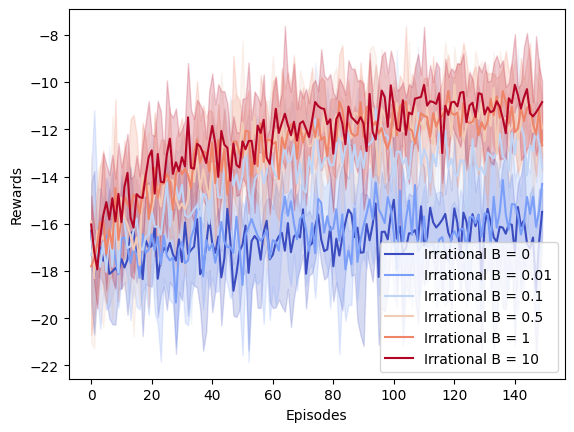

In [131]:
import matplotlib.pyplot as plt
cmap = plt.get_cmap('coolwarm')

num_curves = 6  # Adjust based on the number of datasets
colors = [cmap(i / (num_curves - 1)) for i in range(num_curves)]

fig, ax1 = plt.subplots()

# Plot each curve with gradient colors
datasets = [
    (reward_wo_irr_0, 'Irrational B = 0'),
    (reward_wo_irr_001, 'Irrational B = 0.01'),
    (reward_wo_irr_01, 'Irrational B = 0.1'),
    (reward_wo_irr_05, 'Irrational B = 0.5'),
    (reward_wo_irr_1, 'Irrational B = 1'),
    (reward_wo_irr_10, 'Irrational B = 10'),
]

for idx, (data, label) in enumerate(datasets):
    mean_values = np.mean(data, axis=0)
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    ax1.plot(mean_values, color=colors[idx], label=label)
    ax1.fill_between(range(len(mean_values)), min_values, max_values, color=colors[idx], alpha=0.2)

# Add legend and labels
ax1.legend()
ax1.set_xlabel('Episodes')
ax1.set_ylabel('Rewards')
plt.show()
# ax1.plot(np.mean(reward_wo_irr_10, axis=0), color='lightcoral', label='Irrational B = 10')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_10, axis=0), np.max(reward_wo_irr_10, axis=0), color='lightcoral', alpha=0.2)

# ax1.plot(np.mean(reward_wo_irr_100, axis=0), color='firebrick', label='Irrational B = 100')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_100, axis=0), np.max(reward_wo_irr_100, axis=0), color='firebrick', alpha=0.2)

# ax1.plot(np.mean(reward_wo_irr_1000, axis=0), color='darkred', label='Irrational B = 1000')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_1000, axis=0), np.max(reward_wo_irr_1000, axis=0), color='darkred', alpha=0.2)

ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward (excl. adversarial)')
ax1.set_title('Training Rewards Over Time')
ax1.grid(True, alpha=0.1)
ax1.legend()

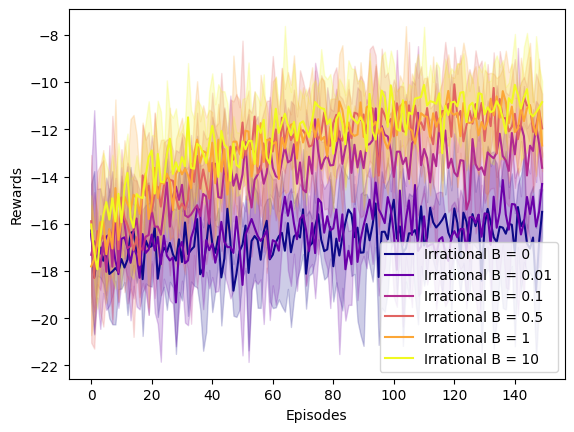

In [146]:
import matplotlib.pyplot as plt
cmap = plt.get_cmap('plasma')

num_curves = 6  # Adjust based on the number of datasets
colors = [cmap(i / (num_curves - 1)) for i in range(num_curves)]

fig, ax1 = plt.subplots()

# Plot each curve with gradient colors
datasets = [
    (reward_wo_irr_0, 'Irrational B = 0'),
    (reward_wo_irr_001, 'Irrational B = 0.01'),
    (reward_wo_irr_01, 'Irrational B = 0.1'),
    (reward_wo_irr_05, 'Irrational B = 0.5'),
    (reward_wo_irr_1, 'Irrational B = 1'),
    (reward_wo_irr_10, 'Irrational B = 10'),
]

for idx, (data, label) in enumerate(datasets):
    mean_values = np.mean(data, axis=0)
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    ax1.plot(mean_values, color=colors[idx], label=label)
    ax1.fill_between(range(len(mean_values)), min_values, max_values, color=colors[idx], alpha=0.2)

# Add legend and labels
ax1.legend()
ax1.set_xlabel('Episodes')
ax1.set_ylabel('Rewards')
plt.show()
# ax1.plot(np.mean(reward_wo_irr_10, axis=0), color='lightcoral', label='Irrational B = 10')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_10, axis=0), np.max(reward_wo_irr_10, axis=0), color='lightcoral', alpha=0.2)

# ax1.plot(np.mean(reward_wo_irr_100, axis=0), color='firebrick', label='Irrational B = 100')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_100, axis=0), np.max(reward_wo_irr_100, axis=0), color='firebrick', alpha=0.2)

# ax1.plot(np.mean(reward_wo_irr_1000, axis=0), color='darkred', label='Irrational B = 1000')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_1000, axis=0), np.max(reward_wo_irr_1000, axis=0), color='darkred', alpha=0.2)

ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward (excl. adversarial)')
ax1.set_title('Training Rewards Over Time')
ax1.grid(True, alpha=0.1)
ax1.legend()

# Compare

In [151]:
def eval_irr_agent(agent, env, episodes):
    rewards = []
    rewards_wo_adv = []
    energy_consumptions = []
    for episode in range(episodes):
        state = env.reset()
        state = torch.tensor([state], dtype=torch.float32).to(agent.device)
        total_reward = 0
        total_energy = 0
        total_reward_no_adv = 0
        for t in range(env.max_steps):
            action = agent.select_action(state)
            
            next_state, reward, done, _ = env.step(action.item())
            reward = torch.tensor([reward], device=agent.device)
            total_reward += reward.item()

            reward_wo_adv = env.get_pmv_wo_irr()
            reward_wo_adv = torch.tensor([reward_wo_adv], device=agent.device)
            total_reward_no_adv += reward_wo_adv.item()

            total_energy += env.hvac_power
            if not done:
                next_state_tensor = torch.tensor([next_state], dtype=torch.float32).to(agent.device)
            else:
                next_state_tensor = None

            state = next_state_tensor
            
        rewards.append(total_reward) # Rewards is a list of increasing cumulative rewards
        rewards_wo_adv.append(total_reward_no_adv)
        energy_consumptions.append(total_energy)
        if (episode + 1) % 10 == 0:
            print(f"Episode {episode + 1}/{episodes} - Reward w adv: {total_reward:.2f}, Reward wo adv: {total_reward_no_adv:.2f}")
    return rewards, energy_consumptions, rewards_wo_adv

In [157]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 128)
        self.layer4 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

class DQNAgent:
    def __init__(self, n_observations, n_actions, device, memory_size=10000, batch_size=64, gamma=0.99, eps_start=0.9, eps_end=0.05, eps_decay=2000, tau=0.005, lr=1e-3):
        self.n_observations = n_observations
        self.n_actions = n_actions
        self.device = device
        self.batch_size = batch_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay 
        self.tau = tau
        self.lr = lr

        self.policy_net = DQN(n_observations, n_actions).to(device)
        self.target_net = DQN(n_observations, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayMemory(memory_size)

        self.steps_done = 0

    def select_action(self, state, train=True):
        if train:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                math.exp(-1. * self.steps_done / self.eps_decay)
            self.steps_done += 1
        else:
            eps_threshold = self.eps_end  
        if random.random() > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        target_net_state_dict = self.target_net.state_dict()
        policy_net_state_dict = self.policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * self.tau + \
                                         target_net_state_dict[key] * (1 - self.tau)
        self.target_net.load_state_dict(target_net_state_dict)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

    def load_model(self, model_path):
        """
        Load a saved policy network from a .pth file into the agent's policy network and update the target network.
        """
        checkpoint = torch.load(model_path, map_location=self.device)
        self.policy_net.load_state_dict(checkpoint)
        self.target_net.load_state_dict(checkpoint)
        self.target_net.eval()
        print(f"Model loaded successfully from {model_path}")

In [160]:
import warnings
warnings.filterwarnings('ignore')

def run_multiple_irr_evals(num_trials, env_with_adv, episodes):
    print("------ RUNNING multiple experiments for env:" + str(env_with_adv))
    all_rewards = []
    all_rewards_wo_ad = []
    agent = DQNAgent(n_observations=3, n_actions=9, device=torch.device("cpu"))
    model_path = "protagonist_model_with_energy.pth"
    agent.load_model(model_path)

    for i in range(num_trials):
        print("TRIAL: #" + str(i))
        env_with_adv.reset()
        # env_with_adv = AdversarialBuildingEnv(adversarial_prob=1, adversarial_fraction=adversarial_fraction)
        # agent_with_adv = DQNAgent(n_observations=env_with_adv.observation_space.shape[0], n_actions=env_with_adv.action_space.n, device=device)
        rewards_with_adv, _, rewards_wo_adv = eval_irr_agent(agent, env_with_adv, episodes=episodes)
        all_rewards.append(rewards_with_adv)
        all_rewards_wo_ad.append(rewards_wo_adv)
    return all_rewards, all_rewards_wo_ad

In [163]:
rarl_reward_irr_001, rarl_reward_wo_irr_001 = run_multiple_irr_evals(num_trials, IrrationalBuildingEnv(irrational_B=0.01), EPISODES)
rarl_reward_irr_01, rarl_reward_wo_irr_01 = run_multiple_irr_evals(num_trials, IrrationalBuildingEnv(irrational_B=0.1), EPISODES)
rarl_reward_irr_05, rarl_reward_wo_irr_05 = run_multiple_irr_evals(num_trials, IrrationalBuildingEnv(irrational_B=0.5), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
Model loaded successfully from protagonist_model_with_energy.pth
TRIAL: #0
Episode 10/150 - Reward w adv: -2.34, Reward wo adv: -15.22
Episode 20/150 - Reward w adv: -2.50, Reward wo adv: -15.87
Episode 30/150 - Reward w adv: -2.04, Reward wo adv: -12.87
Episode 40/150 - Reward w adv: -2.52, Reward wo adv: -16.04
Episode 50/150 - Reward w adv: -2.12, Reward wo adv: -14.52
Episode 60/150 - Reward w adv: -2.34, Reward wo adv: -11.79
Episode 70/150 - Reward w adv: -2.00, Reward wo adv: -10.79
Episode 80/150 - Reward w adv: -1.93, Reward wo adv: -11.08
Episode 90/150 - Reward w adv: -1.97, Reward wo adv: -10.54
Episode 100/150 - Reward w adv: -2.08, Reward wo adv: -11.10
Episode 110/150 - Reward w adv: -1.83, Reward wo adv: -10.22
Episode 120/150 - Reward w adv: -1.93, Reward wo adv: -12.83
Episode 130/150 - Reward w adv: -1.56, Reward wo adv: -9.51
Episode 140/150 - Reward w adv: -1.36, Reward wo adv: -9.70
Episo

In [161]:
rarl_reward_irr_1, rarl_reward_wo_irr_1 = run_multiple_irr_evals(num_trials, IrrationalBuildingEnv(irrational_B=1), EPISODES)

------ RUNNING multiple experiments for env:<IrrationalBuildingEnv instance>
Model loaded successfully from protagonist_model_with_energy.pth
TRIAL: #0
Episode 10/150 - Reward w adv: -12.25, Reward wo adv: -14.75
Episode 20/150 - Reward w adv: -12.43, Reward wo adv: -15.17
Episode 30/150 - Reward w adv: -11.29, Reward wo adv: -13.93
Episode 40/150 - Reward w adv: -11.78, Reward wo adv: -13.77
Episode 50/150 - Reward w adv: -8.86, Reward wo adv: -8.46
Episode 60/150 - Reward w adv: -9.28, Reward wo adv: -13.80
Episode 70/150 - Reward w adv: -8.60, Reward wo adv: -12.08
Episode 80/150 - Reward w adv: -8.58, Reward wo adv: -8.41
Episode 90/150 - Reward w adv: -7.38, Reward wo adv: -9.47
Episode 100/150 - Reward w adv: -8.44, Reward wo adv: -11.41
Episode 110/150 - Reward w adv: -7.54, Reward wo adv: -10.04
Episode 120/150 - Reward w adv: -8.10, Reward wo adv: -9.95
Episode 130/150 - Reward w adv: -8.50, Reward wo adv: -11.18
Episode 140/150 - Reward w adv: -9.08, Reward wo adv: -10.52
Epi

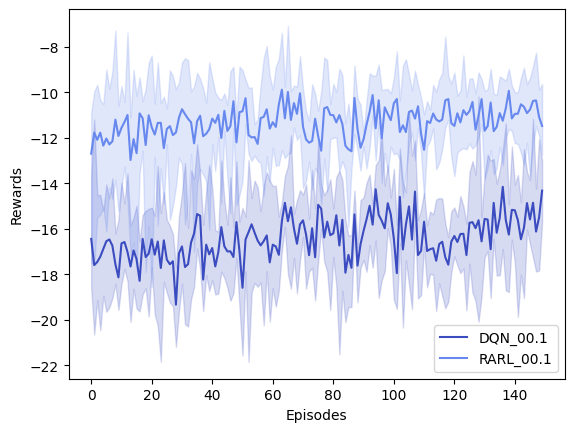

In [174]:
import matplotlib.pyplot as plt
cmap = plt.get_cmap('coolwarm')

num_curves = 8  # Adjust based on the number of datasets
colors = [cmap(i / (num_curves - 1)) for i in range(num_curves)]

fig, ax1 = plt.subplots()

# Plot each curve with gradient colors
datasets = [
    (reward_wo_irr_001, 'DQN_00.1'),
    (rarl_reward_wo_irr_001, 'RARL_00.1'),
    # (reward_wo_irr_01, 'DQN_0.1'),
    # (rarl_reward_wo_irr_01, 'RARL_0.1'),
    # (reward_wo_irr_05, 'DQN_0.5'),
    # (rarl_reward_wo_irr_05, 'RARL_0.5'),
    # (reward_wo_irr_1, 'DQN_1'),
    # (rarl_reward_wo_irr_1, 'RARL_1'),
]

for idx, (data, label) in enumerate(datasets):
    mean_values = np.mean(data, axis=0)
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    ax1.plot(mean_values, color=colors[idx], label=label)
    ax1.fill_between(range(len(mean_values)), min_values, max_values, color=colors[idx], alpha=0.2)

# Add legend and labels
ax1.legend()
ax1.set_xlabel('Episodes')
ax1.set_ylabel('Rewards')
plt.show()
# ax1.plot(np.mean(reward_wo_irr_10, axis=0), color='lightcoral', label='Irrational B = 10')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_10, axis=0), np.max(reward_wo_irr_10, axis=0), color='lightcoral', alpha=0.2)

# ax1.plot(np.mean(reward_wo_irr_100, axis=0), color='firebrick', label='Irrational B = 100')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_100, axis=0), np.max(reward_wo_irr_100, axis=0), color='firebrick', alpha=0.2)

# ax1.plot(np.mean(reward_wo_irr_1000, axis=0), color='darkred', label='Irrational B = 1000')
# ax1.fill_between(range(EPISODES), np.min(reward_wo_irr_1000, axis=0), np.max(reward_wo_irr_1000, axis=0), color='darkred', alpha=0.2)

ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward (excl. adversarial)')
ax1.set_title('Training Rewards Over Time')
ax1.grid(True, alpha=0.1)
ax1.legend()